<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/3_Project/4_Salary_Analysis.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# How well do jobs and skills pay for Data Analysts?

#### Methodology
1. Evaluate median salary for top data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

#### Original Exploration

[18_Matplotlib_Box_Plots.ipynb](../2_Advanced/18_Matplotlib_Box_Plots.ipynb)  
[19_Exercise_Skill_Pay_Analysis.ipynb](../2_Advanced/19_Exercise_Skill_Pay_Analysis.ipynb)

## Import Libraries and Data

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_data

# Load the cleaned data_jobs dataset.
# First run downloads it from Hugging Face and caches it to data/data_jobs.parquet;
# every later run reads that cache instead. See load_data.py for the details.
df = load_data()

## Salary Distribution by Job Title

Filter our data to only include salary values from a selected country.

In [2]:
selected_country = 'Israel'
# filter for the job titles and country
df_country = df[(df['job_country'] == selected_country)].dropna(subset=['salary_year_avg'])

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [3]:
job_titles = df_country['job_title_short'].value_counts().sort_values(ascending=False)
job_titles

job_title_short
Data Scientist               24
Data Analyst                 23
Machine Learning Engineer    14
Data Engineer                13
Senior Data Engineer          9
Senior Data Scientist         8
Senior Data Analyst           5
Software Engineer             5
Cloud Engineer                1
Business Analyst              1
Name: count, dtype: int64

In [4]:
# top_jobs = 6
# job_titles = df_country['job_title_short'].value_counts().index[:top_jobs].tolist()
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer', 'Senior Data Scientist', 'Senior Data Engineer', 'Senior Data Analyst'] # explicitly naming jobs

# filter the df for the top_jobs job titles
df_country_top = df_country[df_country['job_title_short'].isin(job_titles)]

# order the job titles by median salary
job_order = df_country_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles
# df_country_top
# job_order

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

## Plot Salary Distributions

Plot the top job titles salary distributions using a box plot.

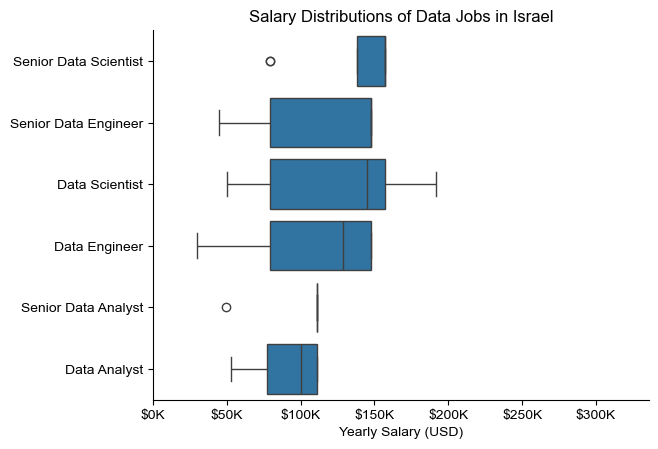

In [5]:
sns.boxplot(data=df_country_top, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

# this is all the same
plt.title('Salary Distributions of Data Jobs in ' + selected_country)
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
# plt.xlim(0, 600000) # constant x limit

salary_cap = df_country_top['salary_year_avg'].quantile(0.99) # dynamic x limit
# salary_cap = df_country_top['salary_year_avg'].max() # # constant x limit, more sensitive to outliers
plt.xlim(0, salary_cap * 1.75)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

Filters the original dataset to only get rows where the job title is 'Data Analyst' and a country of your choosing, to create a new DataFrame `df_country_da`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in the DataFrame for each skill associated with a job. Finally, it displays the first five entries of the `salary_year_avg` and `job_skills` columns.

In [6]:
top_n_skills = 5
# Only get data analyst jobs in selected country
df_country_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == selected_country)].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_country_da = df_country_da.dropna(subset=['salary_year_avg'])

df_country_da = df_country_da.explode('job_skills')

df_country_da[['salary_year_avg', 'job_skills']].head(top_n_skills)

,salary_year_avg,job_skills
2818,111175.0,python
26522,111175.0,gdpr
118018,79200.0,sql
118018,79200.0,python
160995,72000.0,nosql


## Determine The Highest Paid Skills and Most Demanded Skills

Gets the top ten highest-paying skills for Data Analysts by calculating the median salary for each skill listed in the `df_country_da`. It groups the data by job skills, computes the median salary, sorts these values in descending order by median, and then selects the top 10. This is then formatted into a new DataFrame (`df_country_da_top_pay`) with a reset index and a renamed salary column labeled 'median_salary'.

In [7]:
df_country_da_top_pay = df_country_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_country_da_top_pay = df_country_da_top_pay.head(10)

df_country_da_top_pay

,count,median
job_skills,,
gdpr,1,111175.0
snowflake,1,111175.0
python,14,111175.0
r,2,108087.5
go,4,108087.5
pandas,1,105000.0
numpy,1,105000.0
sql,17,100500.0
jupyter,1,100500.0


Calculates the count and median salary for each skill in `df_country_da`. It groups the data by `job_skills`, aggregates it to find the count and median salary for each skill, and then sorts the results by count in descending order by count. It re-sorts this subset by median salary in descending order.

In [8]:
df_country_da_top_skills = df_country_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_country_da_top_skills = df_country_da_top_skills.head(10).sort_values(by='median', ascending=False)

df_country_da_top_skills

,count,median
job_skills,,
python,14,111175.0
go,4,108087.5
r,2,108087.5
sql,17,100500.0
tableau,6,95187.5
power bi,2,93195.5
looker,2,82094.5
excel,2,79007.0
nosql,1,72000.0


Creates two horizontal bar charts: 
1. Displays the highest paid skills 
2. Shows the most in demand skills 

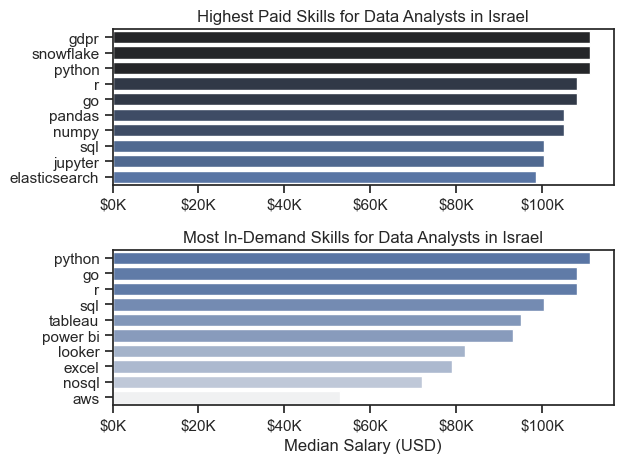

In [9]:
fig, ax = plt.subplots(2, 1)  

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_country_da_top_pay, x='median', y=df_country_da_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_country_da_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Highest Paid Skills for Data Analysts in ' + selected_country)
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts')
sns.barplot(data=df_country_da_top_skills, x='median', y=df_country_da_top_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_country_da_top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Most In-Demand Skills for Data Analysts in ' + selected_country)
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()